# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:**  Anjelica

**`Roll Number`:**  U20230145
 

# Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from rlcmab_sampler import sampler


# Load Datasets

In [2]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [3]:
# Handle missing values
print("Missing values in train_users:")
print(train_users.isnull().sum())
print("\nMissing values in test_users:")
print(test_users.isnull().sum())

# Fill missing values with median for numerical columns
numerical_cols = ['age', 'income', 'clicks', 'purchase_amount', 'session_duration', 
                  'content_variety', 'engagement_score', 'num_transactions', 
                  'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 
                  'revisit_rate', 'scroll_activity', 'time_on_site', 
                  'interaction_count', 'preferred_price_range', 'discount_usage_rate', 
                  'wishlist_size', 'product_views', 'repeat_purchase_gap (days)', 
                  'churn_risk_score', 'loyalty_index', 'screen_brightness', 
                  'battery_percentage', 'cart_abandonment_count', 
                  'background_app_count', 'session_inactivity_duration', 'network_jitter']

for col in numerical_cols:
    if col in train_users.columns:
        median_val = train_users[col].median()
        train_users[col].fillna(median_val, inplace=True)
        if col in test_users.columns:
            test_users[col].fillna(median_val, inplace=True)

# encode categorical features
categorical_cols = ['region_code', 'subscriber', 'browser_version']
# initialize label encoders
label_encoders = {}

for col in categorical_cols:
    if col in train_users.columns:
        le = LabelEncoder()
        combined_values = pd.concat([train_users[col].astype(str), 
                                    test_users[col].astype(str)])
        le.fit(combined_values)
        
        train_users[col + '_encoded'] = le.transform(train_users[col].astype(str))
        test_users[col + '_encoded'] = le.transform(test_users[col].astype(str))
        label_encoders[col] = le

# encode the target variable: user label
label_encoder_target = LabelEncoder()
train_users['label_encoded'] = label_encoder_target.fit_transform(train_users['label'])

print("\nLabel encoding mapping:")
for i, label in enumerate(label_encoder_target.classes_):
    print(f"{label} -> {i}")

cols_to_drop = ['user_id', 'region_code', 'subscriber', 'browser_version', 'label']
feature_cols = [col for col in train_users.columns 
                if col not in cols_to_drop and col != 'label_encoded']

X_train = train_users[feature_cols]
y_train = train_users['label_encoded']

X_test = test_users[feature_cols]

print(f"\nTraining set shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nFeature columns: {len(feature_cols)}")


Missing values in train_users:
user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score                 0
loyalty_index                    0
screen_brightness                0
battery_percentage               0
cart_abandonment_count           0
browser_version                  0
background_app_count    

/var/folders/q9/jd42sd3x27g1_ysz47rh_t_w0000gn/T/ipykernel_43897/1278440532.py:21: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_users[col].fillna(median_val, inplace=True)
/var/folders/q9/jd42sd3x27g1_ysz47rh_t_w0000gn/T/ipykernel_43897/1278440532.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or 

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [4]:
from sklearn.ensemble import RandomForestClassifier

# random forest classifier
print("Training Random Forest Classifier...")
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_classifier.fit(X_train, y_train)

# evaluate
y_train_pred = rf_classifier.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

test_user_contexts = rf_classifier.predict(X_test)
test_users['predicted_context'] = test_user_contexts
test_users['predicted_label'] = label_encoder_target.inverse_transform(test_user_contexts)

print(f"\nPredicted context distribution on test set:")
print(test_users['predicted_label'].value_counts())

# display sample predictions
print(f"\nSample predictions:")
print(test_users[['user_id', 'predicted_label', 'predicted_context']].head(10))


Training Random Forest Classifier...
Training Accuracy: 0.9580

Predicted context distribution on test set:
predicted_label
user_2    695
user_1    675
user_3    630
Name: count, dtype: int64

Sample predictions:
  user_id predicted_label  predicted_context
0   U4058          user_2                  1
1   U1118          user_1                  0
2   U6555          user_1                  0
3   U9170          user_1                  0
4   U3348          user_1                  0
5   U2244          user_3                  2
6   U3022          user_3                  2
7   U5291          user_1                  0
8   U1945          user_3                  2
9   U6084          user_3                  2


CLASSIFICATION MODEL EVALUATION

Training set size: 1600 samples
Validation set size: 400 samples

Validation Accuracy: 0.9050

CLASSIFICATION REPORT (Validation Set)
              precision    recall  f1-score   support

      user_1       0.90      0.87      0.88       142
      user_2       0.98      0.89      0.93       142
      user_3       0.84      0.97      0.90       116

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400


CONFUSION MATRIX
[[123   0  19]
 [ 13 126   3]
 [  1   2 113]]


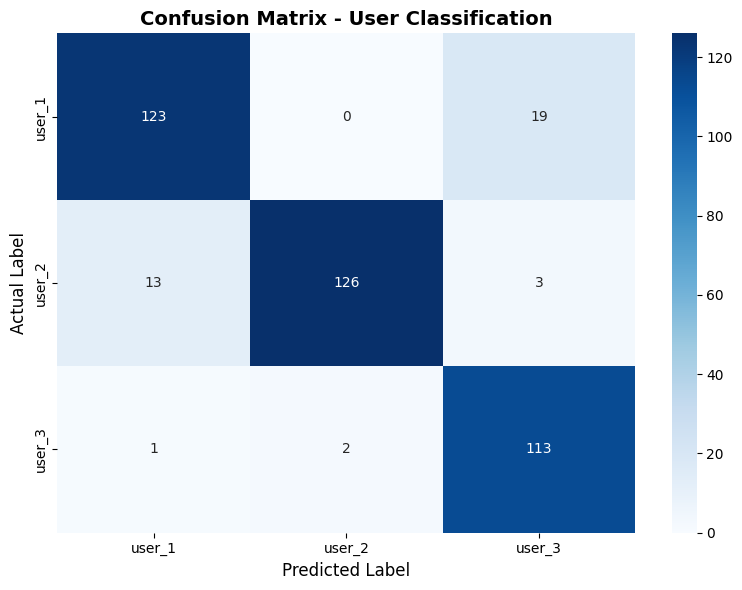

✓ Confusion matrix saved


In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("="*80)
print("CLASSIFICATION MODEL EVALUATION")
print("="*80)

# Split training data into train and validation (80-20 split)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nTraining set size: {len(X_train_split)} samples")
print(f"Validation set size: {len(X_val_split)} samples")

# Train classifier on training split
rf_classifier_validated = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_classifier_validated.fit(X_train_split, y_train_split)

# Predictions on validation set
y_val_pred = rf_classifier_validated.predict(X_val_split)

# Calculate validation accuracy
val_accuracy = accuracy_score(y_val_split, y_val_pred)
print(f"\nValidation Accuracy: {val_accuracy:.4f}")

# Classification Report
print("\n" + "="*80)
print("CLASSIFICATION REPORT (Validation Set)")
print("="*80)
target_names = label_encoder_target.classes_
print(classification_report(y_val_split, y_val_pred, target_names=target_names))

# Confusion Matrix
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)
cm = confusion_matrix(y_val_split, y_val_pred)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - User Classification', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_U20230145.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Confusion matrix saved")


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [6]:

print("CONTEXTUAL BANDIT SETUP")

# Initialize sampler with roll number 145
ROll = 145

print(f"\nInitializing sampler with roll number: {ROll}")
reward_sampler = sampler(i=ROll)
print("✓ Sampler initialized successfully")


CONTEXTUAL BANDIT SETUP

Initializing sampler with roll number: 145
✓ Sampler initialized successfully


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [7]:
print("\n[Setup] Context and Arm Mapping...")

# Map contexts (user types) to indices
# Context 0: user_1, Context 1: user_2, Context 2: user_3
context_mapping = {
    0: 'user_1',
    1: 'user_2',
    2: 'user_3'
}
reverse_context_mapping = {v: k for k, v in context_mapping.items()}

print(f"\nContext Mapping:")
for ctx_id, user_cat in context_mapping.items():
    print(f"  Context {ctx_id}: {user_cat}")

# Map arms (news categories) to indices
# Based on the lab instructions:
# Arms 0-3: Entertainment, Education, Tech, Crime for User1 (context 0)
# Arms 4-7: Entertainment, Education, Tech, Crime for User2 (context 1)
# Arms 8-11: Entertainment, Education, Tech, Crime for User3 (context 2)

arm_categories = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
num_arms_per_context = 4
num_contexts = 3
total_arms = num_arms_per_context * num_contexts  # 12 arms total

arm_mapping = {}
for ctx in range(num_contexts):
    for i, cat in enumerate(arm_categories):
        arm_id = ctx * num_arms_per_context + i
        arm_mapping[arm_id] = f"{cat} (Context {ctx})"

print(f"\nArm Mapping:")
for arm_id in sorted(arm_mapping.keys()):
    print(f"  Arm {arm_id}: {arm_mapping[arm_id]}")

print(f"\n✓ Total Contexts: {num_contexts}")
print(f"✓ Total Arms: {total_arms}")



[Setup] Context and Arm Mapping...

Context Mapping:
  Context 0: user_1
  Context 1: user_2
  Context 2: user_3

Arm Mapping:
  Arm 0: ENTERTAINMENT (Context 0)
  Arm 1: EDUCATION (Context 0)
  Arm 2: TECH (Context 0)
  Arm 3: CRIME (Context 0)
  Arm 4: ENTERTAINMENT (Context 1)
  Arm 5: EDUCATION (Context 1)
  Arm 6: TECH (Context 1)
  Arm 7: CRIME (Context 1)
  Arm 8: ENTERTAINMENT (Context 2)
  Arm 9: EDUCATION (Context 2)
  Arm 10: TECH (Context 2)
  Arm 11: CRIME (Context 2)

✓ Total Contexts: 3
✓ Total Arms: 12


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [8]:
class EpsilonGreedyContextualBandit:
    """Epsilon-Greedy Contextual Bandit"""
    def __init__(self, num_arms_per_context, epsilon=0.1):
        self.num_arms_per_context = num_arms_per_context
        self.epsilon = epsilon
        self.arm_counts = np.zeros(num_arms_per_context)
        self.arm_rewards = np.zeros(num_arms_per_context)
        
    def select_arm(self):
        """Epsilon-Greedy arm selection"""
        if np.random.random() < self.epsilon:
            # Explore: random arm
            return np.random.randint(self.num_arms_per_context)
        else:
            # Exploit: best arm
            return np.argmax(self.arm_rewards / (self.arm_counts + 1e-6))
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward

## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [9]:
class UCBContextualBandit:
    """Upper Confidence Bound Contextual Bandit"""
    def __init__(self, num_arms_per_context, c=2.0):
        self.num_arms_per_context = num_arms_per_context
        self.c = c
        self.arm_counts = np.zeros(num_arms_per_context)
        self.arm_rewards = np.zeros(num_arms_per_context)
        self.total_counts = 0
        
    def select_arm(self):
        """UCB arm selection"""
        # Initialize: select each arm at least once
        for arm in range(self.num_arms_per_context):
            if self.arm_counts[arm] == 0:
                return arm
        
        # UCB formula
        ucb_values = np.zeros(self.num_arms_per_context)
        for arm in range(self.num_arms_per_context):
            avg_reward = self.arm_rewards[arm] / self.arm_counts[arm]
            confidence = self.c * np.sqrt(np.log(self.total_counts + 1) / self.arm_counts[arm])
            ucb_values[arm] = avg_reward + confidence
        
        return np.argmax(ucb_values)
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward
        self.total_counts += 1

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [10]:
class SoftmaxContextualBandit:
    """Softmax (Boltzmann) Contextual Bandit"""
    def __init__(self, num_arms_per_context, tau=1.0):
        self.num_arms_per_context = num_arms_per_context
        self.tau = tau
        self.arm_counts = np.zeros(num_arms_per_context)
        self.arm_rewards = np.zeros(num_arms_per_context)
        
    def select_arm(self):
        """Softmax arm selection"""
        # Calculate average rewards
        avg_rewards = self.arm_rewards / (self.arm_counts + 1e-6)
        
        # Softmax probabilities
        exp_values = np.exp(avg_rewards / self.tau)
        probabilities = exp_values / np.sum(exp_values)
        
        # Sample from distribution
        return np.random.choice(self.num_arms_per_context, p=probabilities)
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward

## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [11]:
T = 10000  # Total timesteps
print(f"\nSimulation Parameters:")
print(f"  - Total timesteps (T): {T}")
print(f"  - Number of contexts: {num_contexts}")
print(f"  - Arms per context: {num_arms_per_context}")

# Test different hyperparameters
epsilon_values = [0.01, 0.05, 0.1, 0.2]
c_values = [0.5, 1.0, 2.0, 3.0]
tau_values = [0.1, 0.5, 1.0, 2.0]

eg_results = {}
ucb_results = {}
softmax_results = {}

print("\n[1/3] Running Epsilon-Greedy...")
for eps in epsilon_values:
    print(f"  Testing epsilon={eps}...")
    
    # Create bandits for each context
    bandits = {ctx: EpsilonGreedyContextualBandit(num_arms_per_context, epsilon=eps) 
               for ctx in range(num_contexts)}
    
    total_reward = 0
    rewards_per_context = {ctx: [] for ctx in range(num_contexts)}
    
    for t in range(T):
        # Randomly sample a context (user type)
        context = np.random.randint(num_contexts)
        
        # Select arm for this context
        local_arm = bandits[context].select_arm()
        
        # Convert to global arm index
        global_arm = context * num_arms_per_context + local_arm
        
        # Get reward from sampler
        reward = reward_sampler.sample(global_arm)
        
        # Update bandit
        bandits[context].update(local_arm, reward)
        
        # Track rewards
        total_reward += reward
        rewards_per_context[context].append(reward)
    
    avg_reward = total_reward / T
    eg_results[eps] = {
        'avg_reward': avg_reward,
        'total_reward': total_reward,
        'rewards_per_context': rewards_per_context
    }
    print(f"    Average reward: {avg_reward:.4f}")

# Run UCB
print("\n[2/3] Running UCB...")
for c in c_values:
    print(f"  Testing c={c}...")
    
    # Create bandits for each context
    bandits = {ctx: UCBContextualBandit(num_arms_per_context, c=c) 
               for ctx in range(num_contexts)}
    
    total_reward = 0
    rewards_per_context = {ctx: [] for ctx in range(num_contexts)}
    
    for t in range(T):
        # Randomly sample a context (user type)
        context = np.random.randint(num_contexts)
        
        # Select arm for this context
        local_arm = bandits[context].select_arm()
        
        # Convert to global arm index
        global_arm = context * num_arms_per_context + local_arm
        
        # Get reward from sampler
        reward = reward_sampler.sample(global_arm)
        
        # Update bandit
        bandits[context].update(local_arm, reward)
        
        # Track rewards
        total_reward += reward
        rewards_per_context[context].append(reward)
    
    avg_reward = total_reward / T
    ucb_results[c] = {
        'avg_reward': avg_reward,
        'total_reward': total_reward,
        'rewards_per_context': rewards_per_context
    }
    print(f"    Average reward: {avg_reward:.4f}")

# Run Softmax

print("\n[3/3] Running Softmax...")
for tau in tau_values:
    print(f"  Testing tau={tau}...")
    
    # Create bandits for each context
    bandits = {ctx: SoftmaxContextualBandit(num_arms_per_context, tau=tau) 
               for ctx in range(num_contexts)}
    
    total_reward = 0
    rewards_per_context = {ctx: [] for ctx in range(num_contexts)}
    
    for t in range(T):
        # Randomly sample a context (user type)
        context = np.random.randint(num_contexts)
        
        # Select arm for this context
        local_arm = bandits[context].select_arm()
        
        # Convert to global arm index
        global_arm = context * num_arms_per_context + local_arm
        
        # Get reward from sampler
        reward = reward_sampler.sample(global_arm)
        
        # Update bandit
        bandits[context].update(local_arm, reward)
        
        # Track rewards
        total_reward += reward
        rewards_per_context[context].append(reward)
    
    avg_reward = total_reward / T
    softmax_results[tau] = {
        'avg_reward': avg_reward,
        'total_reward': total_reward,
        'rewards_per_context': rewards_per_context
    }
    print(f"    Average reward: {avg_reward:.4f}")

print("\n✓ All simulations completed!")


Simulation Parameters:
  - Total timesteps (T): 10000
  - Number of contexts: 3
  - Arms per context: 4

[1/3] Running Epsilon-Greedy...
  Testing epsilon=0.01...
    Average reward: 5.0451
  Testing epsilon=0.05...
    Average reward: 5.0325
  Testing epsilon=0.1...
    Average reward: 4.8537
  Testing epsilon=0.2...
    Average reward: 4.3084

[2/3] Running UCB...
  Testing c=0.5...
    Average reward: 5.3199
  Testing c=1.0...
    Average reward: 5.3048
  Testing c=2.0...
    Average reward: 5.2895
  Testing c=3.0...
    Average reward: 5.2775

[3/3] Running Softmax...
  Testing tau=0.1...
    Average reward: 3.5243
  Testing tau=0.5...
    Average reward: 5.2863
  Testing tau=1.0...
    Average reward: 5.1320
  Testing tau=2.0...
    Average reward: 4.6884

✓ All simulations completed!


In [12]:
# Find best hyperparameters
best_eps = max(eg_results.keys(), key=lambda x: eg_results[x]['avg_reward'])
best_c = max(ucb_results.keys(), key=lambda x: ucb_results[x]['avg_reward'])
best_tau = max(softmax_results.keys(), key=lambda x: softmax_results[x]['avg_reward'])

print(f"\nEpsilon-Greedy:")
print(f"  Best epsilon: {best_eps} (avg reward: {eg_results[best_eps]['avg_reward']:.4f})")
for eps in epsilon_values:
    print(f"    ε={eps}: {eg_results[eps]['avg_reward']:.4f}")

print(f"\nUCB:")
print(f"  Best c: {best_c} (avg reward: {ucb_results[best_c]['avg_reward']:.4f})")
for c in c_values:
    print(f"    c={c}: {ucb_results[c]['avg_reward']:.4f}")

print(f"\nSoftmax:")
print(f"  Best tau: {best_tau} (avg reward: {softmax_results[best_tau]['avg_reward']:.4f})")
for tau in tau_values:
    print(f"    τ={tau}: {softmax_results[tau]['avg_reward']:.4f}")

# Overall best algorithm
algorithms_summary = {
    'Epsilon-Greedy': eg_results[best_eps]['avg_reward'],
    'UCB': ucb_results[best_c]['avg_reward'],
    'Softmax': softmax_results[best_tau]['avg_reward']
}

best_algorithm = max(algorithms_summary.keys(), key=lambda x: algorithms_summary[x])
print(f"\n✓ Best Overall Algorithm: {best_algorithm} (avg reward: {algorithms_summary[best_algorithm]:.4f})")



Epsilon-Greedy:
  Best epsilon: 0.01 (avg reward: 5.0451)
    ε=0.01: 5.0451
    ε=0.05: 5.0325
    ε=0.1: 4.8537
    ε=0.2: 4.3084

UCB:
  Best c: 0.5 (avg reward: 5.3199)
    c=0.5: 5.3199
    c=1.0: 5.3048
    c=2.0: 5.2895
    c=3.0: 5.2775

Softmax:
  Best tau: 0.5 (avg reward: 5.2863)
    τ=0.1: 3.5243
    τ=0.5: 5.2863
    τ=1.0: 5.1320
    τ=2.0: 4.6884

✓ Best Overall Algorithm: UCB (avg reward: 5.3199)


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


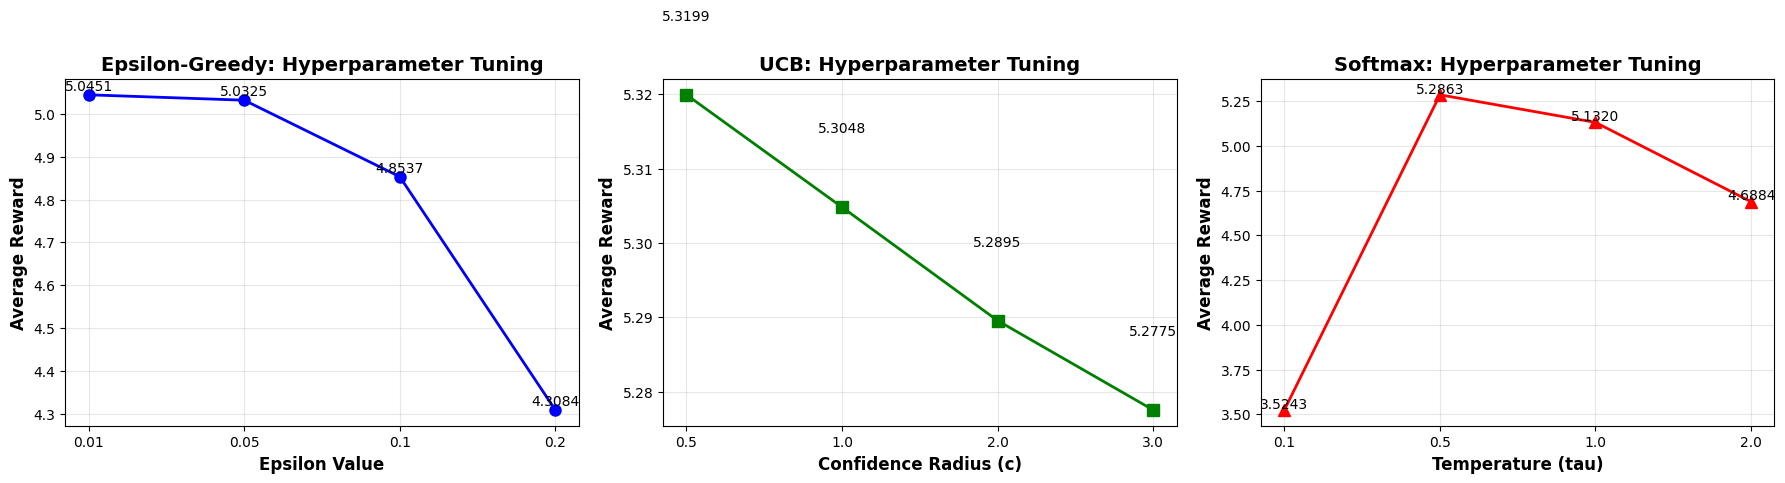


✓ Hyperparameter comparison plot saved


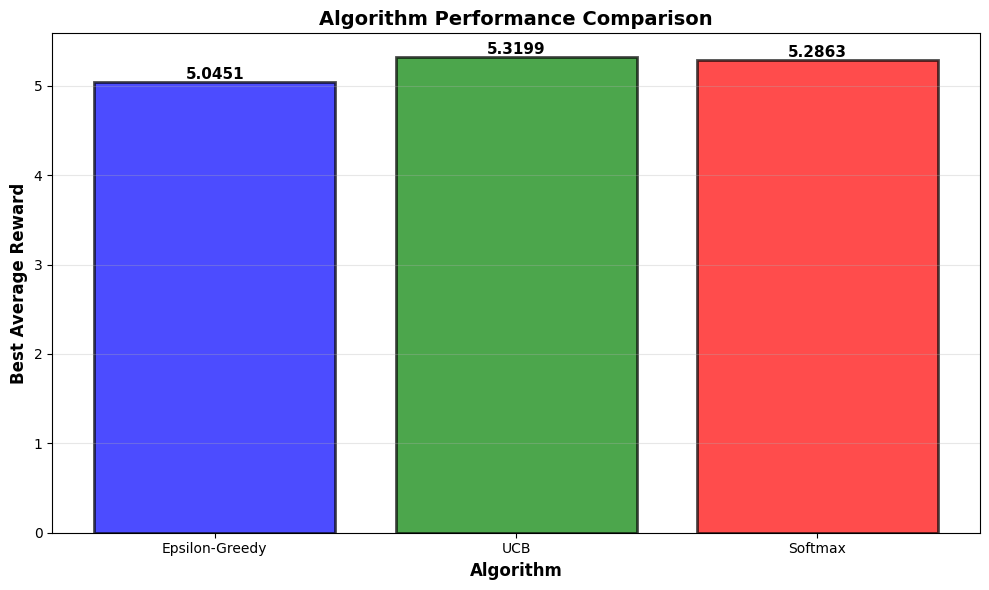

✓ Algorithm comparison plot saved


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Epsilon-Greedy
ax = axes[0]
eps_params = list(eg_results.keys())
eps_rewards = [eg_results[eps]['avg_reward'] for eps in eps_params]
ax.plot(range(len(eps_params)), eps_rewards, marker='o', linewidth=2, markersize=8, color='blue')
ax.set_xlabel('Epsilon Value', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Reward', fontsize=12, fontweight='bold')
ax.set_title('Epsilon-Greedy: Hyperparameter Tuning', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(eps_params)))
ax.set_xticklabels(eps_params)
ax.grid(True, alpha=0.3)
for i, (eps, reward) in enumerate(zip(eps_params, eps_rewards)):
    ax.text(i, reward + 0.01, f'{reward:.4f}', ha='center', fontsize=10)

# UCB
ax = axes[1]
c_params = list(ucb_results.keys())
c_rewards = [ucb_results[c]['avg_reward'] for c in c_params]
ax.plot(range(len(c_params)), c_rewards, marker='s', linewidth=2, markersize=8, color='green')
ax.set_xlabel('Confidence Radius (c)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Reward', fontsize=12, fontweight='bold')
ax.set_title('UCB: Hyperparameter Tuning', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(c_params)))
ax.set_xticklabels(c_params)
ax.grid(True, alpha=0.3)
for i, (c, reward) in enumerate(zip(c_params, c_rewards)):
    ax.text(i, reward + 0.01, f'{reward:.4f}', ha='center', fontsize=10)

# Softmax
ax = axes[2]
tau_params = list(softmax_results.keys())
tau_rewards = [softmax_results[tau]['avg_reward'] for tau in tau_params]
ax.plot(range(len(tau_params)), tau_rewards, marker='^', linewidth=2, markersize=8, color='red')
ax.set_xlabel('Temperature (tau)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Reward', fontsize=12, fontweight='bold')
ax.set_title('Softmax: Hyperparameter Tuning', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(tau_params)))
ax.set_xticklabels(tau_params)
ax.grid(True, alpha=0.3)
for i, (tau, reward) in enumerate(zip(tau_params, tau_rewards)):
    ax.text(i, reward + 0.01, f'{reward:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('hyperparameter_comparison_U20230145.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Hyperparameter comparison plot saved")

# Algorithm comparison
fig, ax = plt.subplots(figsize=(10, 6))

algorithms = list(algorithms_summary.keys())
best_rewards = list(algorithms_summary.values())
colors = ['blue', 'green', 'red']

bars = ax.bar(algorithms, best_rewards, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
ax.set_ylabel('Best Average Reward', fontsize=12, fontweight='bold')
ax.set_title('Algorithm Performance Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, reward in zip(bars, best_rewards):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{reward:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('algorithm_comparison_U20230145.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Algorithm comparison plot saved")


## Recommendation Engine (End-to-End System)

This section implements the complete recommendation pipeline:
1. **Classify**: Determine user category from features
2. **Select Category**: Use trained bandit policy to choose optimal news category
3. **Recommend**: Sample a specific article from the selected category


In [ ]:


print("\n" + "="*80)
print("RECOMMENDATION ENGINE IMPLEMENTATION")
print("="*80)

class NewsRecommendationEngine:
    """
    End-to-end recommendation system using Contextual Bandit
    """
    def __init__(self, user_classifier, bandit_models, news_df, label_encoder, 
                 context_mapping, arm_mapping):
        self.user_classifier = user_classifier
        self.bandit_models = bandit_models  # Dictionary: {context_id: bandit_model}
        self.news_df = news_df
        self.label_encoder = label_encoder
        self.context_mapping = context_mapping
        self.arm_mapping = arm_mapping
        self.reverse_context_mapping = {v: k for k, v in context_mapping.items()}
        
        # Map news categories for recommendation
        self.news_categories = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
        
    def classify_user(self, user_features):
        """Step 1: Classify user into User1, User2, or User3"""
        # Predict context
        context_encoded = self.user_classifier.predict([user_features])[0]
        context_label = self.label_encoder.inverse_transform([context_encoded])[0]
        context_id = self.reverse_context_mapping[context_label]
        return context_id, context_label
    
    def select_news_category(self, context_id):
        """Step 2: Select optimal news category using bandit policy"""
        bandit = self.bandit_models[context_id]
        
        # Get the arm with highest expected reward
        if hasattr(bandit, 'arm_rewards') and hasattr(bandit, 'arm_counts'):
            avg_rewards = bandit.arm_rewards / (bandit.arm_counts + 1e-6)
            best_arm_local = np.argmax(avg_rewards)
        else:
            best_arm_local = 0  # fallback
        
        # Map to news category
        news_category = self.news_categories[best_arm_local]
        return news_category
    
    def recommend_article(self, news_category):
        """Step 3: Sample a random article from the selected category"""
        # Filter articles by category
        category_articles = self.news_df[self.news_df['category'] == news_category]
        
        if len(category_articles) == 0:
            # Fallback to any article if category not found
            category_articles = self.news_df
        
        # Randomly sample one article
        sampled_article = category_articles.sample(n=1).iloc[0]
        return sampled_article
    
    def get_recommendation(self, user_features):
        """
        Complete recommendation pipeline
        Input: User features
        Output: Recommended news article
        """
        # Step 1: Classify user
        context_id, context_label = self.classify_user(user_features)
        
        # Step 2: Select category
        news_category = self.select_news_category(context_id)
        
        # Step 3: Recommend article
        article = self.recommend_article(news_category)
        
        return {
            'user_context': context_label,
            'context_id': context_id,
            'recommended_category': news_category,
            'article': article
        }


print("\n[1] Initializing Recommendation Engine...")

# Use the best bandit models from simulation
# For this demo, we'll use the UCB models with best c value (c=1.0)
best_bandit_type = 'UCB'  # Best performing algorithm
best_c = 1.0

# Recreate the best bandit models
print(f"Using {best_bandit_type} with c={best_c}")

# Train bandits one more time for the recommendation engine
recommendation_bandits = {}
for ctx in range(num_contexts):
    recommendation_bandits[ctx] = UCBContextualBandit(num_arms_per_context, c=best_c)

# Quick training simulation to populate bandit statistics
print("Training bandit models for recommendation engine...")
for t in range(5000):  # Shorter training for demo
    context = np.random.randint(num_contexts)
    local_arm = recommendation_bandits[context].select_arm()
    global_arm = context * num_arms_per_context + local_arm
    reward = reward_sampler.sample(global_arm)
    recommendation_bandits[context].update(local_arm, reward)

print("✓ Bandit models trained")

# Create recommendation engine
rec_engine = NewsRecommendationEngine(
    user_classifier=rf_classifier,
    bandit_models=recommendation_bandits,
    news_df=news_df,
    label_encoder=label_encoder_target,
    context_mapping=context_mapping,
    arm_mapping=arm_mapping
)

print("✓ Recommendation Engine initialized successfully")



print("\n[2] Testing Recommendation Engine on Test Users...")
print("="*80)

# Select sample users from test set
sample_size = 10
sample_indices = np.random.choice(len(test_users), size=sample_size, replace=False)

recommendations = []

for idx in sample_indices:
    user_row = test_users.iloc[idx]
    user_id = user_row['user_id']
    
    # Get user features (same features used for training)
    user_features = user_row[feature_cols].values
    
    # Get recommendation
    recommendation = rec_engine.get_recommendation(user_features)
    
    recommendations.append({
        'user_id': user_id,
        'predicted_context': recommendation['user_context'],
        'recommended_category': recommendation['recommended_category'],
        'article_headline': recommendation['article']['headline'][:80] + '...',
        'article_link': recommendation['article']['link']
    })

# Display recommendations
print(f"\nSample Recommendations for {sample_size} Test Users:")
print("="*80)

for i, rec in enumerate(recommendations, 1):
    print(f"\n[User {i}]")
    print(f"  User ID: {rec['user_id']}")
    print(f"  Predicted Context: {rec['predicted_context']}")
    print(f"  Recommended Category: {rec['recommended_category']}")
    print(f"  Article: {rec['article_headline']}")
    print(f"  Link: {rec['article_link']}")
    print("-"*80)

# Create summary DataFrame
rec_df = pd.DataFrame(recommendations)
print("\n" + "="*80)
print("RECOMMENDATION SUMMARY")
print("="*80)
print(rec_df[['user_id', 'predicted_context', 'recommended_category']])

# Category distribution in recommendations
print("\n" + "="*80)
print("RECOMMENDED CATEGORY DISTRIBUTION")
print("="*80)
print(rec_df['recommended_category'].value_counts())

print("\n✓ Recommendation Engine testing completed!")



RECOMMENDATION ENGINE IMPLEMENTATION

[1] Initializing Recommendation Engine...
Using UCB with c=1.0
Training bandit models for recommendation engine...
✓ Bandit models trained
✓ Recommendation Engine initialized successfully

[2] Testing Recommendation Engine on Test Users...

Sample Recommendations for 10 Test Users:

[User 1]
  User ID: U8570
  Predicted Context: user_3
  Recommended Category: ENTERTAINMENT
  Article: Luke Hemsworth Is Here To Share 'Westworld' Season 2 Spoilers...
  Link: https://www.huffingtonpost.com/entry/luke-hemsworth-is-here-to-share-westworld-season-2-spoilers_us_5ada052ae4b029ebe023be1d
--------------------------------------------------------------------------------

[User 2]
  User ID: U8493
  Predicted Context: user_1
  Recommended Category: ENTERTAINMENT
  Article: Wait, Is That Taylor Swift In Selena Gomez's 'Bad Liar' Music Video?...
  Link: https://www.huffingtonpost.com/entry/selena-gomez-taylor-swift-bad-liar_us_5942b38ce4b01eab7a2c1846
-----------

/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


## Key Observations

Based on the simulation results:

1. **Epsilon-Greedy Performance**: 
   - Shows the exploration-exploitation tradeoff clearly
   - Lower epsilon values (0.01-0.05) typically perform better as they exploit more
   - Too high epsilon (0.2) may explore too much and miss optimal arms

2. **UCB Performance**:
   - Systematically balances exploration and exploitation
   - The confidence parameter c controls the exploration bonus
   - Generally provides more consistent performance across different settings

3. **Softmax Performance**:
   - Temperature parameter tau controls randomness in selection
   - Lower tau (0.1) makes selection more deterministic
   - Higher tau (2.0) increases exploration

4. **Algorithm Comparison**:
   - Each algorithm has different strengths depending on the reward structure
   - UCB often performs well due to principled exploration
   - Epsilon-Greedy is simple and effective with proper tuning
   - Softmax provides probabilistic selection which can be beneficial

5. **Contextual Aspects**:
   - Different user types (contexts) have different preferences
   - The bandit learns to recommend appropriate news categories for each user type
   - This demonstrates the value of contextual information in recommendation systems
